In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from tensorflow import keras
from tensorflow.keras import layers

In [13]:
# 1. CARGA Y LIMPIEZA DE DATOS (Pandas / NumPy)
df = pd.read_csv("sample_data/celulares.csv")

print("Dimensiones del dataset:", df.shape)
print("\nValores nulos por columna:\n", df.isnull().sum())
print("\nDuplicados:", df.duplicated().sum())

df = df.drop_duplicates().dropna()

Dimensiones del dataset: (2000, 21)

Valores nulos por columna:
 battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

Duplicados: 0


In [12]:
print("\nPrimeras filas:")
df.head()


Primeras filas:


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [14]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


<function matplotlib.pyplot.show(close=None, block=None)>

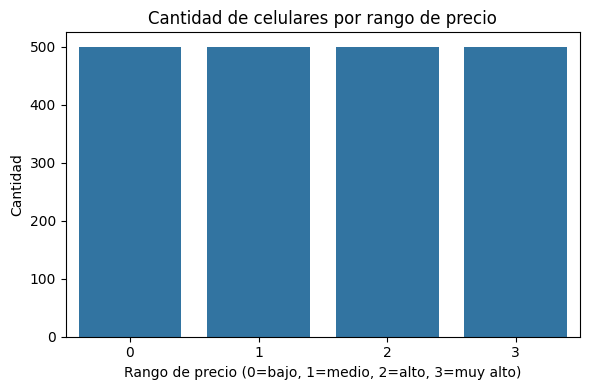

In [20]:
# 2. VISUALIZACIÓN DE DATOS (Matplotlib / Seaborn)
# Distribución de la variable objetivo
plt.figure(figsize=(6, 4))
sns.countplot(x="price_range", data=df)
plt.title("Cantidad de celulares por rango de precio")
plt.xlabel("Rango de precio (0=bajo, 1=medio, 2=alto, 3=muy alto)")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

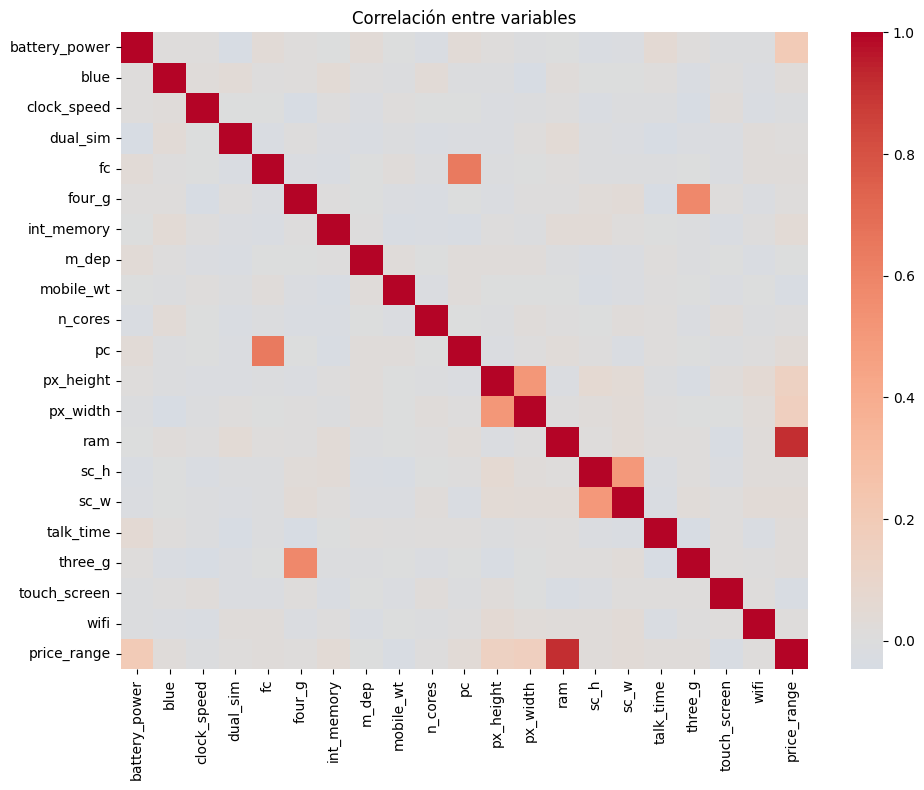

In [19]:
# Mapa de calor de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), cmap="coolwarm", center=0)
plt.title("Correlación entre variables")
plt.tight_layout()
plt.show


Gráficos guardados: distribución, correlación y RAM vs precio.


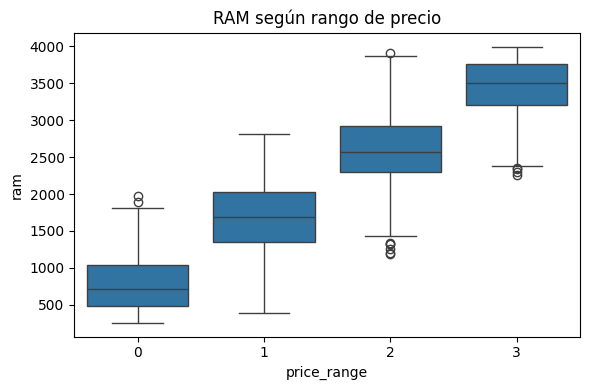

In [18]:
# Relación entre RAM y rango de precio (la variable más influyente)
plt.figure(figsize=(6, 4))
sns.boxplot(x="price_range", y="ram", data=df)
plt.title("RAM según rango de precio")
plt.tight_layout()
plt.show
print("\nGráficos guardados: distribución, correlación y RAM vs precio.")

In [21]:
# 3. PREPARACIÓN PARA MODELADO
# -----------------------------------------------------------------
X = df.drop(columns=["price_range"])
y = df["price_range"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [22]:
# 4. MACHINE LEARNING CLÁSICO (Scikit-learn)
# -----------------------------------------------------------------
modelo_rf = RandomForestClassifier(n_estimators=200, random_state=42)
modelo_rf.fit(X_train_scaled, y_train)

pred_rf = modelo_rf.predict(X_test_scaled)

print("\n===== Random Forest (Scikit-learn) =====")
print("Accuracy:", accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf))

# Importancia de variables
importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nVariables más importantes:\n", importancias.head(5))



===== Random Forest (Scikit-learn) =====
Accuracy: 0.8775
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       100
           1       0.81      0.84      0.82       100
           2       0.82      0.79      0.81       100
           3       0.94      0.93      0.93       100

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.88       400
weighted avg       0.88      0.88      0.88       400


Variables más importantes:
 ram              0.482913
battery_power    0.072960
px_width         0.057762
px_height        0.055650
mobile_wt        0.038956
dtype: float64


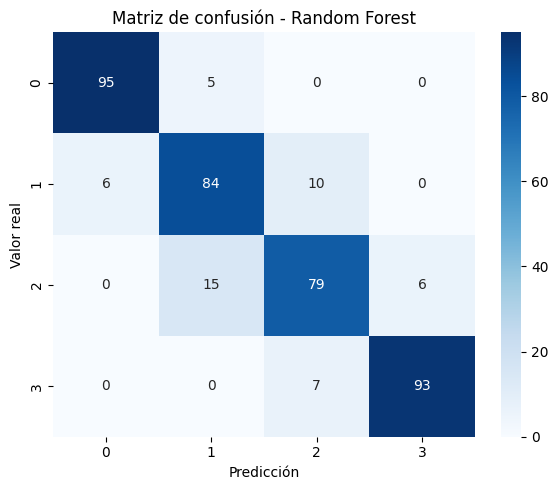

In [25]:
# Matriz de confusión (visual)
matriz = confusion_matrix(y_test, pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.tight_layout()
plt.savefig("grafico_matriz_confusion.png")
plt.show()

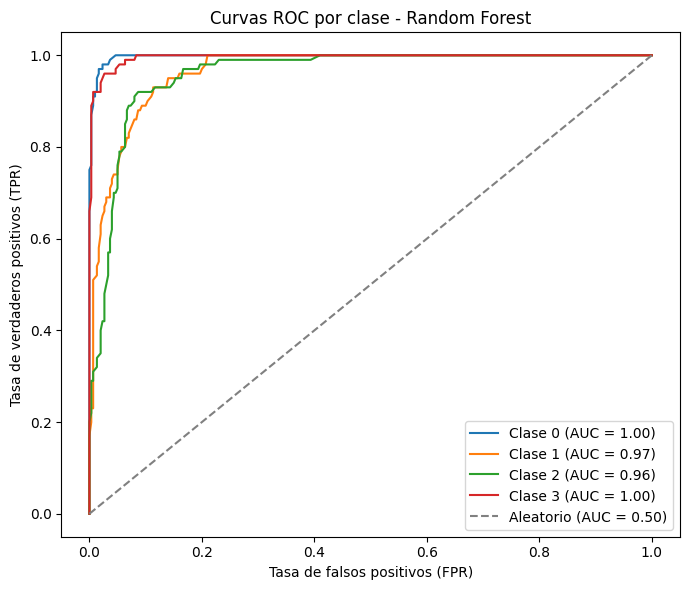

In [33]:
# Curvas ROC y AUC (una por cada clase, enfoque uno-contra-el-resto)
clases = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes=clases)  # convierte 0,1,2,3 en columnas binarias
probas_rf = modelo_rf.predict_proba(X_test_scaled)

plt.figure(figsize=(7, 6))
for i, clase in enumerate(clases):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probas_rf[:, i])
    auc_clase = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Clase {clase} (AUC = {auc_clase:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatorio (AUC = 0.50)")
plt.title("Curvas ROC por clase - Random Forest")
plt.xlabel("Tasa de falsos positivos (FPR)")
plt.ylabel("Tasa de verdaderos positivos (TPR)")
plt.legend()
plt.tight_layout()
plt.savefig("grafico_roc_auc.png")
plt.show()


===== Red Neuronal (TensorFlow/Keras) =====
Accuracy: 0.9399999976158142


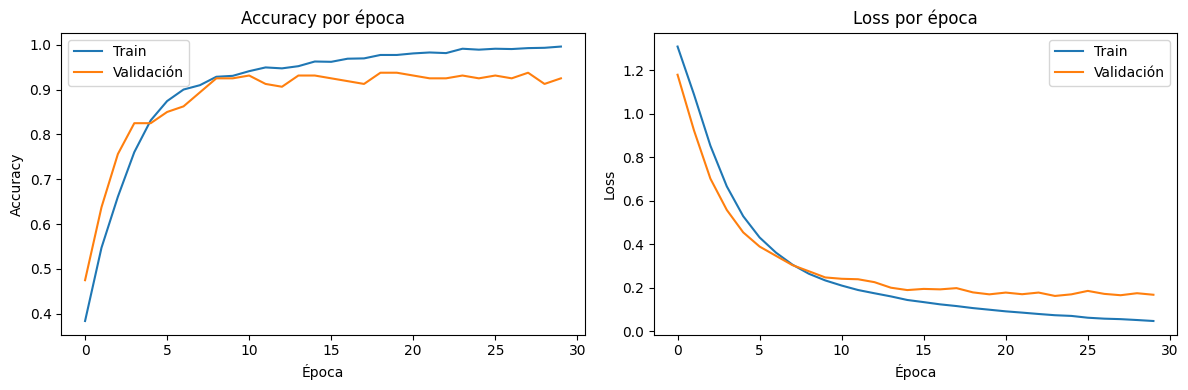

In [30]:
# 5. DEEP LEARNING (TensorFlow / Keras)
# -----------------------------------------------------------------
modelo_dl = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(4, activation="softmax"),  # 4 clases: 0,1,2,3
])

modelo_dl.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

historia = modelo_dl.fit(
    X_train_scaled, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=16,
    verbose=0,
)

loss_dl, acc_dl = modelo_dl.evaluate(X_test_scaled, y_test, verbose=0)
print("\n===== Red Neuronal (TensorFlow/Keras) =====")
print("Accuracy:", acc_dl)

# Curvas de aprendizaje (accuracy y loss por época, lado a lado)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(historia.history["accuracy"], label="Train")
ax1.plot(historia.history["val_accuracy"], label="Validación")
ax1.set_title("Accuracy por época")
ax1.set_xlabel("Época")
ax1.set_ylabel("Accuracy")
ax1.legend()

ax2.plot(historia.history["loss"], label="Train")
ax2.plot(historia.history["val_loss"], label="Validación")
ax2.set_title("Loss por época")
ax2.set_xlabel("Época")
ax2.set_ylabel("Loss")
ax2.legend()

plt.tight_layout()
plt.savefig("grafico_entrenamiento_red_neuronal.png")
plt.show()

In [24]:
# 6. COMPARACIÓN FINAL
# -----------------------------------------------------------------
print("\n===== Comparación de modelos =====")
print(f"Random Forest (Scikit-learn): {accuracy_score(y_test, pred_rf):.3f}")
print(f"Red Neuronal (Keras):         {acc_dl:.3f}")


===== Comparación de modelos =====
Random Forest (Scikit-learn): 0.877
Red Neuronal (Keras):         0.930
